In [20]:
import pandas as pd
import numpy as np

import seaborn as sns
from matplotlib import pyplot as plt
%matplotlib inline

In [19]:
#!wget https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv

In [5]:
df = pd.read_csv("car_fuel_efficiency_2026.csv")
df

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0
...,...,...,...,...,...,...,...,...,...,...,...
9995,2005,USA,Gasoline,All-wheel drive,4,2470,6,271.0,4690,18.9,27.4
9996,1993,Asia,Gasoline,All-wheel drive,2,2300,6,244.0,4370,19.0,30.0
9997,2014,USA,Gasoline,All-wheel drive,3,2480,6,267.0,4590,18.4,28.1
9998,2004,USA,Hybrid,Rear-wheel drive,5,2180,6,270.0,4450,20.9,32.2


In [14]:
col_list = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year', 'fuel_efficiency_mpg']

In [15]:
df = df[col_list]
df

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0
...,...,...,...,...,...
9995,2470,271.0,4690,2005,27.4
9996,2300,244.0,4370,1993,30.0
9997,2480,267.0,4590,2014,28.1
9998,2180,270.0,4450,2004,32.2


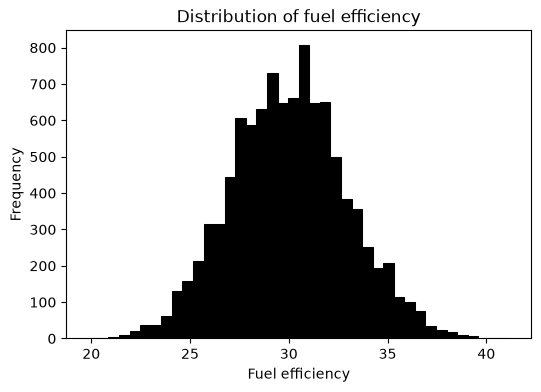

In [22]:
plt.figure(figsize=(6, 4))

sns.histplot(df.fuel_efficiency_mpg, bins=40, color='black', alpha=1)
plt.ylabel('Frequency')
plt.xlabel('Fuel efficiency')
plt.title('Distribution of fuel efficiency')

plt.show()

In [23]:
df.describe()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
count,10000.000000,9123.000000,10000.000000,10000.000000,10000.000000
mean,2268.807000,254.446016,4286.754000,1999.549500,29.997700
std,183.447355,22.844613,266.212491,14.207925,2.930245
min,1590.000000,171.000000,3320.000000,1975.000000,19.800000
25%,2150.000000,239.000000,4110.000000,1987.000000,28.000000
50%,2270.000000,254.000000,4280.000000,2000.000000,30.000000
75%,2390.000000,270.000000,4470.000000,2012.000000,31.900000
max,3110.000000,334.000000,5460.000000,2024.000000,41.200000


In [29]:
# 1. Missing values

df.isnull().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

In [30]:
# 2. Median for horsepower

df.horsepower.describe()

count    9123.000000
mean      254.446016
std        22.844613
min       171.000000
25%       239.000000
50%       254.000000
75%       270.000000
max       334.000000
Name: horsepower, dtype: float64

In [32]:
# 3. Filling NAs

n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

In [33]:
n_train, n_val, n_test

(6000, 2000, 2000)

In [34]:
df_train

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
6252,1900,239.0,3790,2015,32.5
4684,2000,224.0,4380,1992,29.1
1731,2330,286.0,4090,2022,34.1
4742,2300,NaN,4150,1997,30.6
4521,2340,269.0,4400,2001,30.7
...,...,...,...,...,...
7895,2280,242.0,4590,2018,29.8
9590,2300,NaN,4240,1984,25.1
7288,2240,255.0,4190,1989,27.7
278,2430,254.0,4280,2020,31.6


In [41]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

df_train

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,1900,239.0,3790,2015,32.5
1,2000,224.0,4380,1992,29.1
2,2330,286.0,4090,2022,34.1
3,2300,NaN,4150,1997,30.6
4,2340,269.0,4400,2001,30.7
...,...,...,...,...,...
5995,2280,242.0,4590,2018,29.8
5996,2300,NaN,4240,1984,25.1
5997,2240,255.0,4190,1989,27.7
5998,2430,254.0,4280,2020,31.6
